# TDA Assignment — Computing Topology

Topological Data Analysis on six test cases (point clouds, mesh, image).
Each section runs the corresponding test case, shows the input,
persistence diagram and barcode, and reports the computed Betti numbers
against ground truth.

Run all cells with `Kernel ▸ Restart & Run All`.

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "ripser", "persim", "gudhi", "trimesh", "scikit-learn",
    "matplotlib", "pillow", "pandas", "-q"])

In [1]:
import os, sys, time
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))
import numpy as np
import matplotlib.pyplot as plt
from testcases import run_tc1, run_tc2, run_tc3, run_tc4, run_tc5, run_tc6
from tda_core import bottleneck, wasserstein
from make_figures import render_case
%matplotlib inline

## TC1 — Noisy circle in R² (Vietoris-Rips)
Expected Betti: β₀=1, β₁=1.

The diagram should show a single H1 bar with much larger persistence than
the rest — that is the loop of the circle.

Betti [1, 1]   expected [1, 1]   pass: True


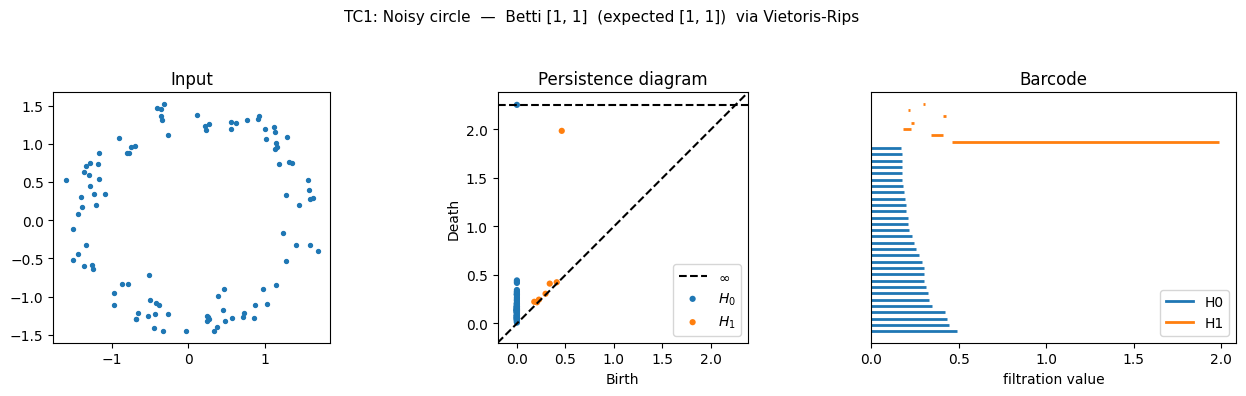

In [2]:
r = run_tc1()
print('Betti', r.betti, '  expected', r.expected, '  pass:', r.passed)
render_case(r); plt.show()

## TC2 — Annulus / square with hole (Alpha complex)
Expected Betti: β₀=1, β₁=1.

The single hole in the centre is detected as one persistent H1 class.

Betti [1, 1, 0]   expected [1, 1]   pass: True


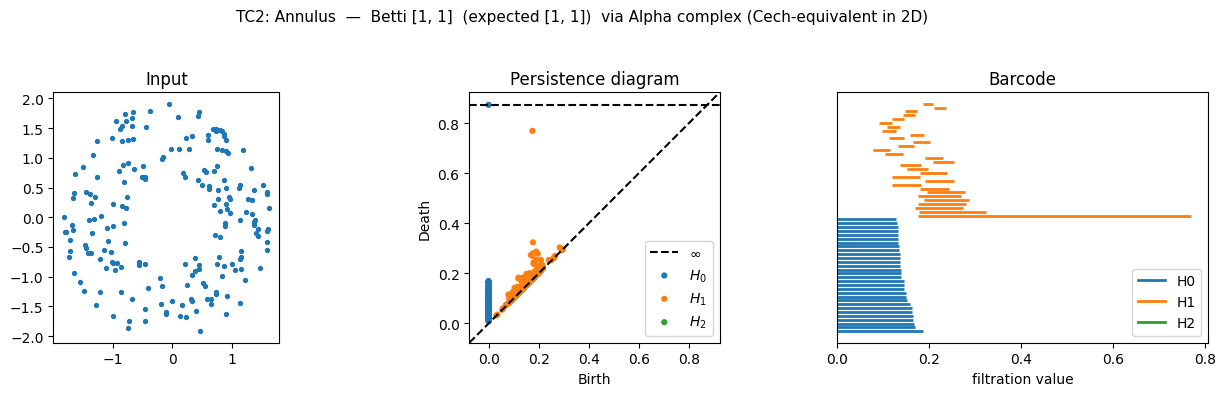

In [3]:
r = run_tc2()
print('Betti', r.betti, '  expected', r.expected, '  pass:', r.passed)
render_case(r); plt.show()

## TC3 — Sphere surface in R³ (Vietoris-Rips)
Expected Betti: β₀=1, β₁=0, β₂=1.

A 2-sphere has a single 2-cavity but no 1-loops; we use a 250-point
subsample to keep maxdim=2 Rips within budget.

Betti [1, 0, 1]   expected [1, 0, 1]   pass: True


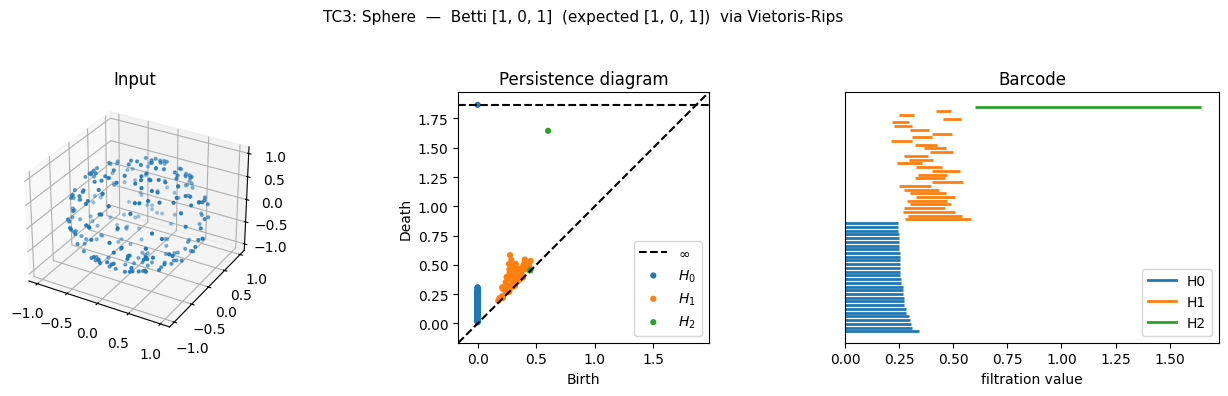

In [4]:
r = run_tc3()
print('Betti', r.betti, '  expected', r.expected, '  pass:', r.passed)
render_case(r); plt.show()

## TC4 — Torus surface (Alpha complex)
Expected Betti: β₀=1, β₁=2, β₂=1.

Two independent 1-cycles (around the tube and through the hole) plus
the central cavity.

Betti [1, 2, 1]   expected [1, 2, 1]   pass: True


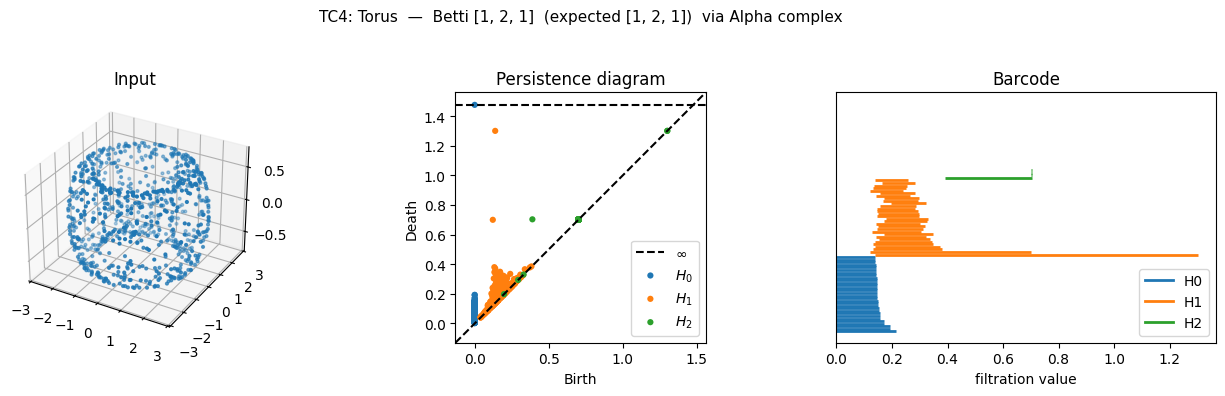

In [5]:
r = run_tc4()
print('Betti', r.betti, '  expected', r.expected, '  pass:', r.passed)
render_case(r); plt.show()

## TC5 — Closed cube mesh (.obj, simplex tree)
Expected Betti: β₀=1, β₁=0, β₂=1 (cube surface is topologically a sphere).

Betti [1, 0, 1]   expected [1, 0, 1]   pass: True


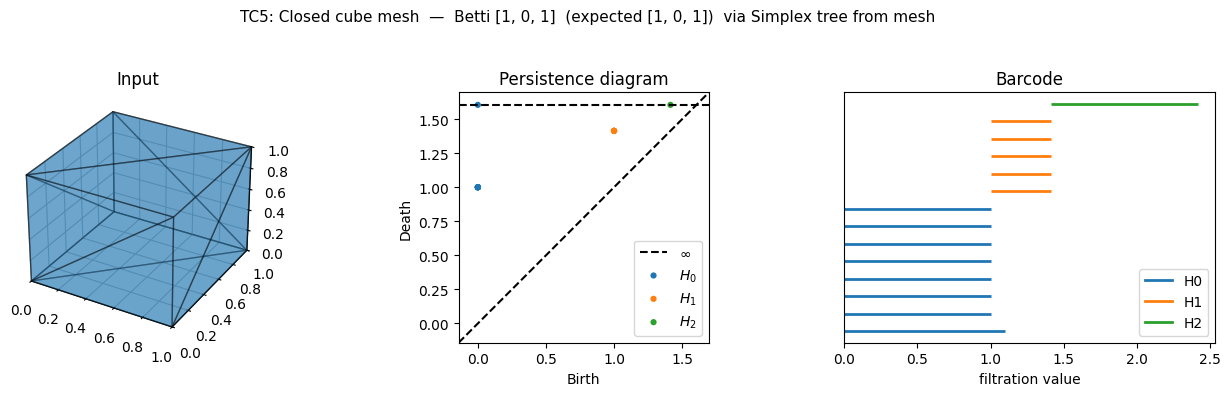

In [6]:
r = run_tc5()
print('Betti', r.betti, '  expected', r.expected, '  pass:', r.passed)
render_case(r); plt.show()

## TC6 — Grayscale image of a circle (cubical complex, sublevel set)
Expected Betti: β₁=1 (the dark ring encloses one bright loop).

Betti [1, 1, 0]   expected [1, 1]   pass: True


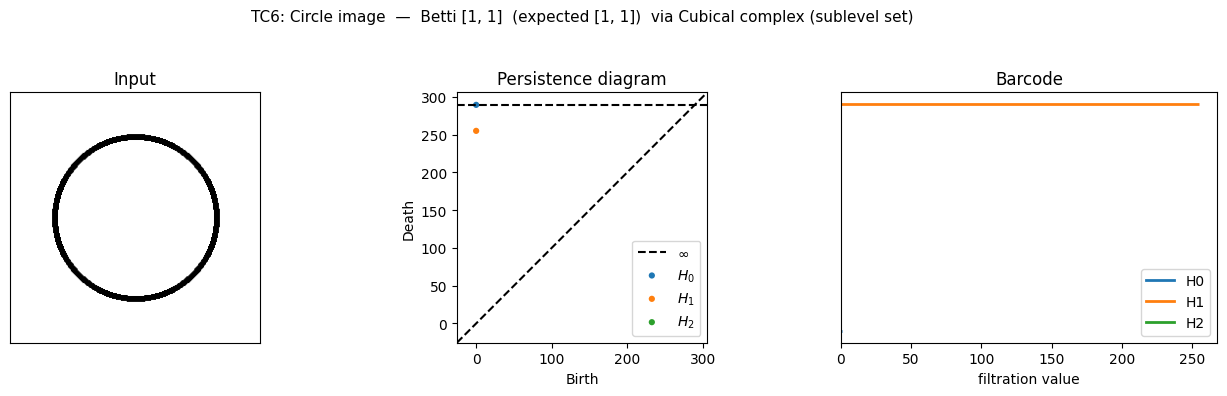

In [7]:
r = run_tc6()
print('Betti', r.betti, '  expected', r.expected, '  pass:', r.passed)
render_case(r); plt.show()

## Diagram comparison — circle vs. annulus

Both shapes share β₁=1 but their H1 features live at different
filtration scales.  We quantify the topological dissimilarity with the
**bottleneck** and **Wasserstein** distances on the H1 diagrams.

In [8]:
r1, r2 = run_tc1(), run_tc2()
print(f'bottleneck H1: {bottleneck(r1.dgms[1], r2.dgms[1]):.4f}')
print(f'wasserstein H1: {wasserstein(r1.dgms[1], r2.dgms[1]):.4f}')

bottleneck H1: 0.7617
wasserstein H1: 2.7675


## Summary table

In [9]:
from testcases import ALL_TESTS
rows = []
for fn in ALL_TESTS:
    t0 = time.time(); r = fn(); dt = time.time() - t0
    rows.append((r.name, r.method, r.expected, r.betti[:len(r.expected)],
                 'PASS' if r.passed else 'FAIL', f'{dt:.2f}s'))
import pandas as pd
pd.DataFrame(rows, columns=['case','method','expected','got','status','time'])

,case,method,expected,got,status,time
0,TC1: Noisy circle,Vietoris-Rips,"[1, 1]","[1, 1]",PASS,0.01s
1,TC2: Annulus,Alpha complex (Cech-equivalent in 2D),"[1, 1]","[1, 1]",PASS,0.01s
2,TC3: Sphere,Vietoris-Rips,"[1, 0, 1]","[1, 0, 1]",PASS,9.97s
3,TC4: Torus,Alpha complex,"[1, 2, 1]","[1, 2, 1]",PASS,0.39s
4,TC5: Closed cube mesh,Simplex tree from mesh,"[1, 0, 1]","[1, 0, 1]",PASS,0.00s
5,TC6: Circle image,Cubical complex (sublevel set),"[1, 1]","[1, 1]",PASS,0.73s
